# デモレース

In [1]:
# 変更部分を適用するリロードのおまじない
%load_ext autoreload
%autoreload 2

# ロガー準備
import logging
import sys

# 1. rootロガーを取得
logger = logging.getLogger()

# 2. ログレベルを設定 (DEBUG, INFO, WARNING など)
logger.setLevel(logging.INFO)

# 3. Jupyterの標準出力に書き出すハンドラを作成
# すでにハンドラが存在する場合は追加しない（二重出力を防ぐ）
if not logger.handlers:
    handler = logging.StreamHandler(sys.stdout)
    
    # 読みやすいフォーマットを設定
    formatter = logging.Formatter('%(levelname)s: %(name)s: %(message)s')
    handler.setFormatter(formatter)
    
    logger.addHandler(handler)

# テスト: これで engine.py 内のログも表示されるようになります
logging.info("Jupyterのロガー設定が完了しました。")

INFO: root: Jupyterのロガー設定が完了しました。


In [6]:
# テスト用レースデータの作成

from src.simulator import RaceSimulator, RaceEvent
from src.services.factory.demo_factory import DemoRaceFactory

# 検証用
from src.services.research_helper import ResearchResultSaver

factory = DemoRaceFactory()
sim = RaceSimulator(factory)
sim.attach(ResearchResultSaver())

# テスト設定
distance = 1600
surface = "dirt"
num_horses = 8

race_info_list = sim.prepare(distance=distance, surface=surface, num_horses=num_horses)

# 準備データ保存
sim.notify(RaceEvent.PREPARE, {'data': race_info_list})

INFO: src.simulator: 初期化中...
INFO: src.core.engine: 初期化中...
INFO: src.services.saver: 初期化中...
INFO: src.services.research_helper: 初期化中...
INFO: src.services.saver: prepared/100001010001_DEMO_dirt1600に結果を保存しました。


In [7]:
# レース実行

for race_info in race_info_list:
    history = sim._run_single_race(race_info)
    sim.results[race_info.race_id] = history
    sim.notify(RaceEvent.FINISH, {'data': race_info, 'history': history})

INFO: src.services.saver: results/100001010001_DEMO_dirt1600に結果を保存しました。
INFO: src.services.research_helper: researchs/100001010001_DEMO_dirt1600に結果を保存しました。


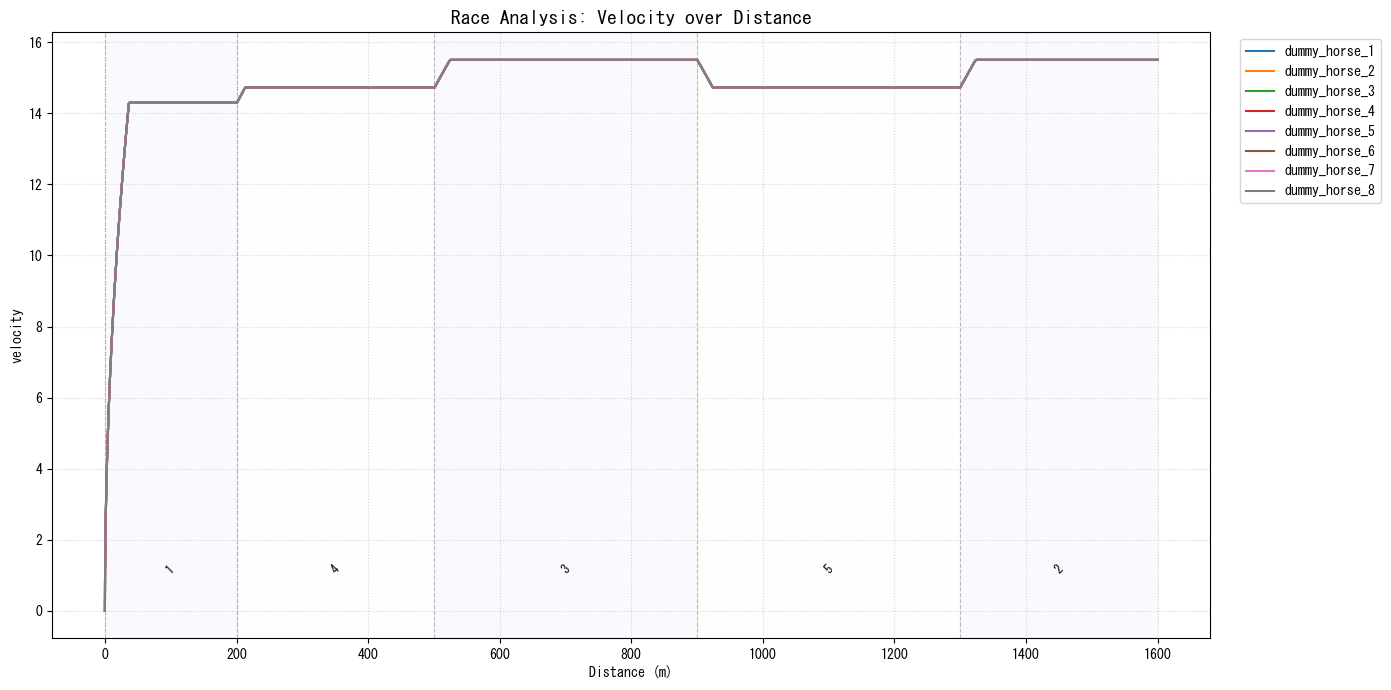

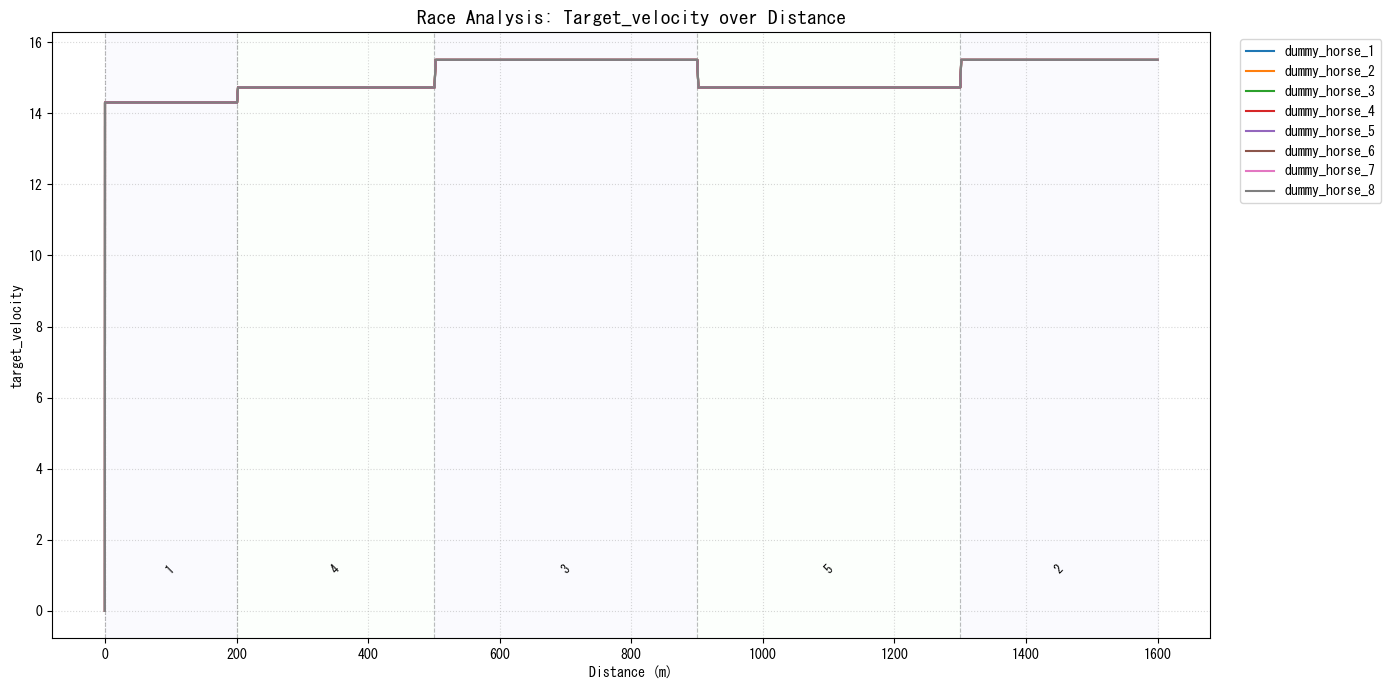

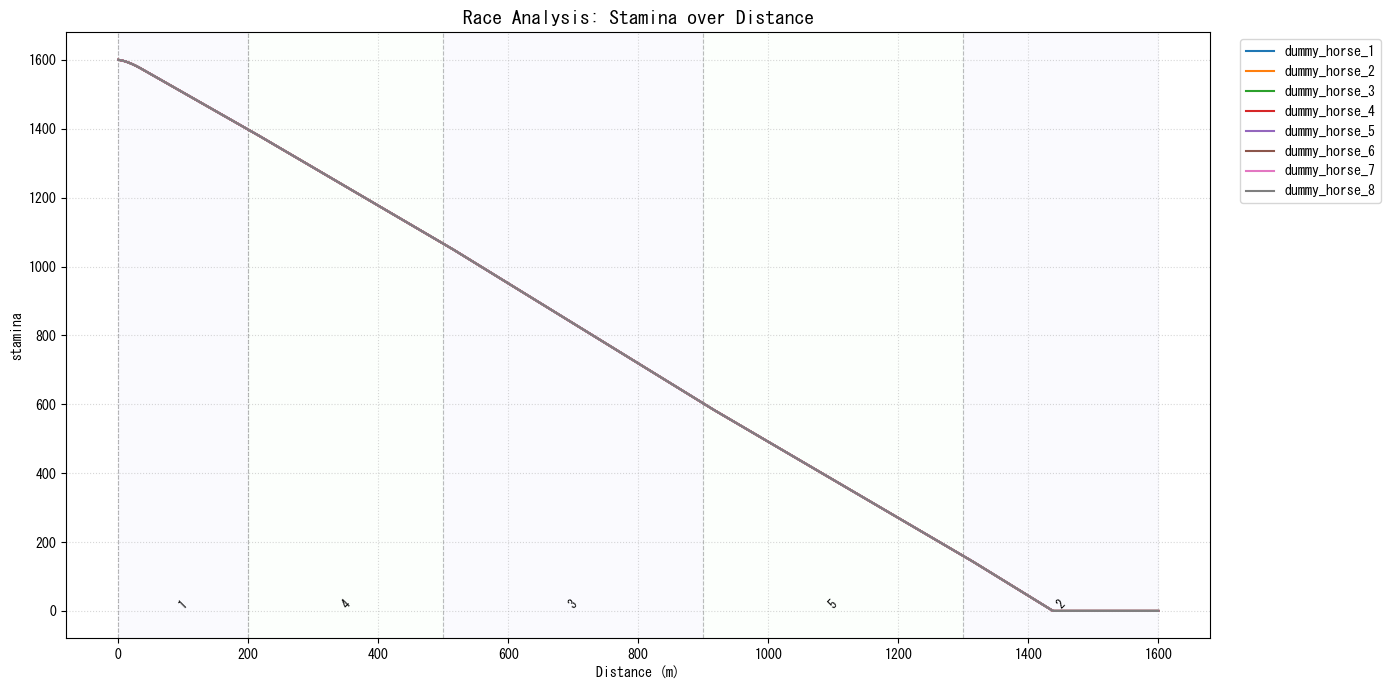

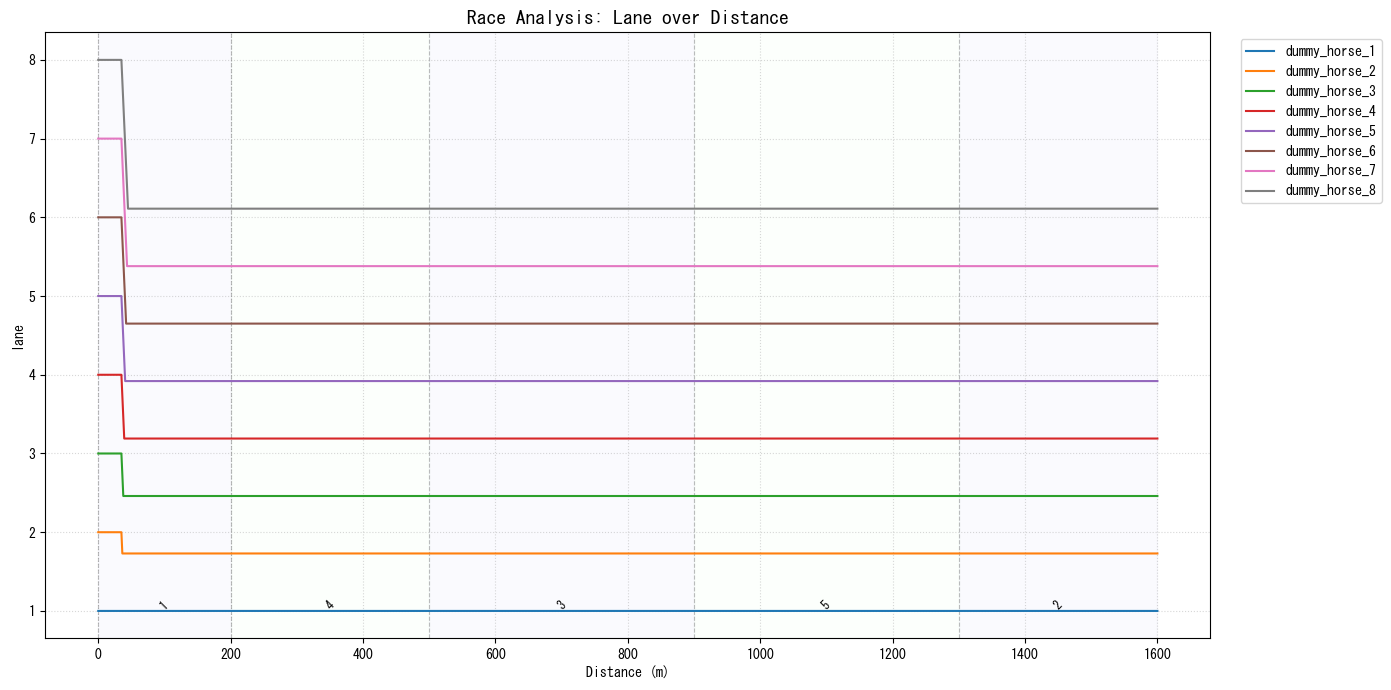

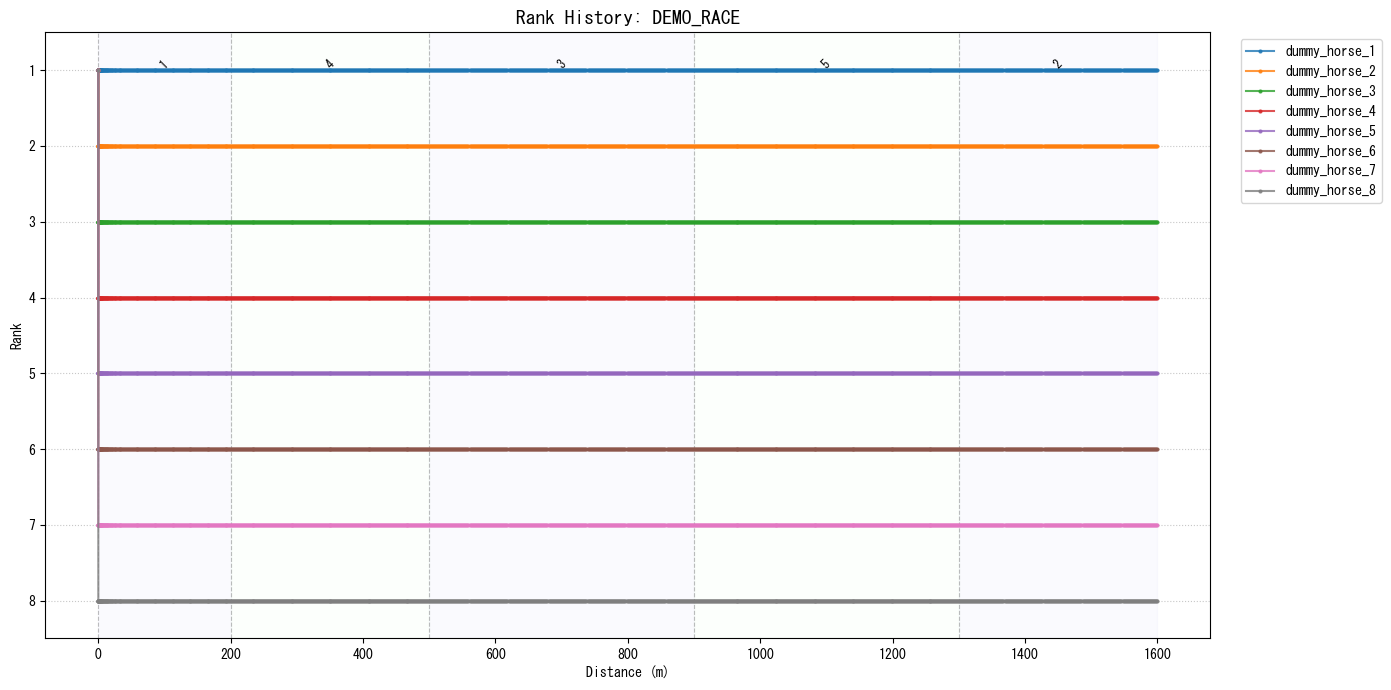

In [8]:
# プロット描画（全レース）
from src.services.research_helper import RaceResultPlotter

plt = RaceResultPlotter()

for race_info in race_info_list:
    history = sim.results[race_info.race_id]
    plt.plot_race_analysis(history, race_info.profile, "velocity")
    plt.plot_race_analysis(history, race_info.profile, "target_velocity")
    plt.plot_race_analysis(history, race_info.profile, "stamina")
    plt.plot_race_analysis(history, race_info.profile, "lane")
    plt.plot_race_rank_history(history, race_info.profile)